In [4]:
import numpy as np
import matplotlib.pyplot as plt

(-16.999299592080213+7.106286644764289j)


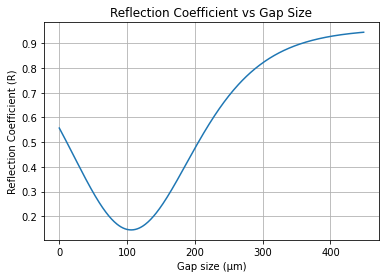

In [7]:
eps_0 = 8.85 * 10**(-12)  # Electric constant
n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
eps_2 = 1  # Dielectric permittivity of air
eps_3 = -14 + 1j * 700  # Dielectric permittivity of the thin dielectric layer on InSb

# Parameters for InSb in the Drude-Lorentz model
wp = 0.578 * 10**14  # Plasma frequency (rad/s)
gp = 1 / 5.16 * 10**13  # Collision frequency (rad/s)
wl = 3.4 * 10**13  # Lorentz frequency (rad/s)
gl = 1 / 3 * 10**12  # Lorentz collision frequency (rad/s)
Al = 2.02  # Amplitude in the Lorentz model
eps_inf = 15.86  # Dielectric permittivity at infinity

wavelength = 197 * 10**(-6)  # Wavelength of radiation
f = 3 * 10**8 / wavelength  # Frequency of radiation
w = 2 * np.pi * f  # Angular frequency

# Drude-Lorentz model for the permittivity of InSb
eps_4 = eps_inf - wp**2 / (w**2 + 1j * gp * w) + Al * wl**2 / (wl**2 - w**2 - 1j * gl * w)
print(eps_4)

# Parameters for the graphene model
d_3 = 35 * 10**(-9)  # Thickness of the studied layer

d_2 = np.arange(0, 450 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb

teta_ext = 40.7  # External angle of incidence on the prism

# Calculate the angle of incidence in the prism
teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))

# Normal components of wave vectors (normalized by k0)
kz_1 = np.sqrt(eps_1) * np.cos(teta)
kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

# Reflection coefficients
r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transmission coefficients
t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transformation matrices
S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

R = np.zeros(len(d_2))  # Initialize reflection coefficient array

for j in range(len(d_2)):
    S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                    [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]])
    
    S = S1 @ S2 @ S3  # Matrix multiplication
    R[j] = (np.abs(S[1, 0] / S[0, 0]))**2

# Plot the results
plt.plot((d_2 - d_3) * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size')
plt.grid()
plt.show()

# Save data to a text file
Data = np.vstack(((d_2 - d_3) * 10**6, R)).T  # Transpose to match format
np.savetxt('R_spp_InSb-PMMA_195_um_teta-42.21.dat', Data, header='d R_spp', fmt='%6s %18s', delimiter='\t', comments='')

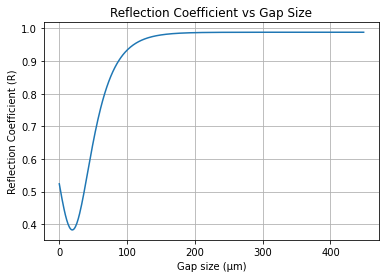

In [5]:
#Same with my parameters

d_3 = 35 * 10**(-9)  # Thickness of the studied layer
teta_ext = 9.10910720e-01*360 /(2*np.pi) # External angle of incidence on the prism
eps_3 = -14 + 1j * 700  # Dielectric permittivity of the thin dielectric layer on InSb




eps_0 = 8.85 * 10**(-12)  # Electric constant
n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
eps_2 = 1  # Dielectric permittivity of air
"""eps_3 = -14 + 1j * 700  # Dielectric permittivity of the thin dielectric layer on InSb"""

# Parameters for InSb in the Drude-Lorentz model
wp = 0.578 * 10**14  # Plasma frequency (rad/s)
gp = 1 / 5.16 * 10**13  # Collision frequency (rad/s)
wl = 3.4 * 10**13  # Lorentz frequency (rad/s)
gl = 1 / 3 * 10**12  # Lorentz collision frequency (rad/s)
Al = 2.02  # Amplitude in the Lorentz model
eps_inf = 15.86  # Dielectric permittivity at infinity

wavelength = 197 * 10**(-6)  # Wavelength of radiation
f = 3 * 10**8 / wavelength  # Frequency of radiation
w = 2 * np.pi * f  # Angular frequency

# Drude-Lorentz model for the permittivity of InSb
eps_4 = eps_inf - wp**2 / (w**2 + 1j * gp * w) + Al * wl**2 / (wl**2 - w**2 - 1j * gl * w)

# Parameters for the graphene model
"""d_3 = 35 * 10**(-9)  # Thickness of the studied layer"""

d_2 = np.arange(0, 450 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb

"""teta_ext = 40.7  # External angle of incidence on the prism"""

# Calculate the angle of incidence in the prism
teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))

# Normal components of wave vectors (normalized by k0)
kz_1 = np.sqrt(eps_1) * np.cos(teta)
kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

# Reflection coefficients
r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transmission coefficients
t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

# Transformation matrices
S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                 np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

R = np.zeros(len(d_2))  # Initialize reflection coefficient array

for j in range(len(d_2)):
    S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                    [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                     np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]])
    
    S = S1 @ S2 @ S3  # Matrix multiplication
    R[j] = (np.abs(S[1, 0] / S[0, 0]))**2

# Plot the results
plt.plot((d_2 - d_3) * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size')
plt.grid()
plt.show()

# Save data to a text file
Data = np.vstack(((d_2 - d_3) * 10**6, R)).T  # Transpose to match format
np.savetxt('R_spp_InSb-PMMA_195_um_teta-42.21.dat', Data, header='d R_spp', fmt='%6s %18s', delimiter='\t', comments='')

In [ ]:
def reflect4(d_2, teta, d_3, eps_re, eps_im): # teta - internal,  d_2 - In+Gr, d_3 - Gr, eps_re/im - gr
    eps_0 = 8.85 * 10**(-12)  # Electric constant
    n_1 = 1.531 - 1j * 0.002  # Complex refractive index of the prism (Zeonex)
    eps_1 = n_1**2  # Dielectric permittivity of the prism (Zeonex)
    eps_2 = 1  # Dielectric permittivity of air
    """eps_3 = -14 + 1j * 700  # Dielectric permittivity of the thin dielectric layer on InSb"""
    eps_3 = eps_re+eps_im*1j
    """# Parameters for InSb in the Drude-Lorentz model
    wp = 0.578 * 10**14  # Plasma frequency (rad/s)
    gp = 1 / 5.16 * 10**13  # Collision frequency (rad/s)
    wl = 3.4 * 10**13  # Lorentz frequency (rad/s)
    gl = 1 / 3 * 10**12  # Lorentz collision frequency (rad/s)
    Al = 2.02  # Amplitude in the Lorentz model
    eps_inf = 15.86  # Dielectric permittivity at infinity

    wavelength = 197 * 10**(-6)  # Wavelength of radiation
    f = 3 * 10**8 / wavelength  # Frequency of radiation
    w = 2 * np.pi * f  # Angular frequency

    # Drude-Lorentz model for the permittivity of InSb
    eps_4 = eps_inf - wp**2 / (w**2 + 1j * gp * w) + Al * wl**2 / (wl**2 - w**2 - 1j * gl * w)"""

    # Parameters for the graphene model
    """d_3 = 35 * 10**(-9)  # Thickness of the studied layer"""

    """d_2 = np.arange(0, 450 * 10**(-6), 1 * 10**(-6))  # Gap size between the prism and InSb"""

    """teta_ext = 40.7  # External angle of incidence on the prism

    # Calculate the angle of incidence in the prism
    teta = 45 * np.pi / 180 - np.arcsin(np.sin((45 - teta_ext) * np.pi / 180) / np.real(n_1))"""

    # Normal components of wave vectors (normalized by k0)
    kz_1 = np.sqrt(eps_1) * np.cos(teta)
    kz_2 = np.sqrt(eps_2 - eps_1 * np.sin(teta)**2)
    kz_3 = np.sqrt(eps_3 - eps_1 * np.sin(teta)**2)
    kz_4 = np.sqrt(eps_4 - eps_1 * np.sin(teta)**2)

    # Reflection coefficients
    r_12 = (eps_2 * kz_1 - eps_1 * kz_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    r_23 = (eps_3 * kz_2 - eps_2 * kz_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    r_34 = (eps_4 * kz_3 - eps_3 * kz_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transmission coefficients
    t_12 = 2 * kz_1 * np.sqrt(eps_1 * eps_2) / (eps_2 * kz_1 + eps_1 * kz_2)
    t_23 = 2 * kz_2 * np.sqrt(eps_2 * eps_3) / (eps_3 * kz_2 + eps_2 * kz_3)
    t_34 = 2 * kz_3 * np.sqrt(eps_3 * eps_4) / (eps_4 * kz_3 + eps_3 * kz_4)

    # Transformation matrices
    S1 = np.array([[1 / t_12, r_12 / t_12], [r_12 / t_12, 1 / t_12]])
    S3 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    r_34 * np.exp(-1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34],
                    [r_34 * np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34,
                    np.exp(1j * (2 * np.pi / wavelength) * kz_3 * d_3) / t_34]])

    R = np.zeros(len(d_2))  # Initialize reflection coefficient array

    for j in range(len(d_2)):
        S2 = np.array([[np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        r_23 * np.exp(-1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23],
                        [r_23 * np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23,
                        np.exp(1j * (2 * np.pi / wavelength) * kz_2 * d_2[j]) / t_23]])
        
        S = S1 @ S2 @ S3  # Matrix multiplication
        R[j] = (np.abs(S[1, 0] / S[0, 0]))**2

# Plot the results
plt.plot((d_2 - d_3) * 10**6, R)  # Convert d_2 to micrometers for plotting
plt.xlabel('Gap size (µm)')
plt.ylabel('Reflection Coefficient (R)')
plt.title('Reflection Coefficient vs Gap Size')
plt.grid()
plt.show()
   